# Exercici Pràctic




In [28]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
import numpy as np
import seaborn as sns

## Carregam les dades: Iris

El dataset Iris és un dels conjunts de dades més coneguts i utilitzats en el camp de l'aprenentatge automàtic i l'estadística. Va ser introduït per Ronald A. Fisher el 1936 en el seu treball sobre l'ús de l'anàlisi discriminant.

Característiques del dataset:

* Nombre de mostres: 150

* Nombre de característiques: 4 variables numèriques contínues:
    - Llargada del sèpal (sepal length).
    - Amplada del sèpal (sepal width).
    - Llargada del pètal (petal length).
    - Amplada del pètal (petal width).

* Nombre de classes: 3 espècies de flors d'iris:
    - Iris-setosa
    - Iris-versicolor
    - Iris-virginica

Cada classe conté 50 mostres

In [15]:
# Càrrega del dataset
iris = load_iris()
X, y = iris.data, iris.target # type: ignore
classes = np.unique(y)
print(classes) # setosa, versicolor, virginica

[0 1 2]


## Tasca

1. Entrenar un model de regressió logística amb el *dataset* Iris, amb la divisió en entrenament i test sense fer cerca d'hiperparàmetres.
2. Entrenar un model de regressió logística amb el *dataset* Iris, amb *cerca d'hiperparàmetres*.
3. Comparar els resultats d'ambdós.

In [19]:
def cross_validate(model, X: np.ndarray, y: np.ndarray, k: int = 5):
  kf = KFold(n_splits=k, shuffle=True, random_state=42)

  scores = []
  for train_idx, test_idx in kf.split(X):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    scores.append(accuracy_score(y_test, y_pred))

  return scores

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [27]:
model = LogisticRegression()

fold_acc = cross_validate(model, X_train, y_train, k=5)
mean_acc = np.mean(fold_acc)
print( "     acc:", ", ".join(f"{x:6.4f}" for x in fold_acc))
print(f"mean acc: {mean_acc:6.4f}")

     acc: 0.9500, 0.9000, 0.9500, 0.9000, 1.0000
mean acc: 0.9400


<Axes: >

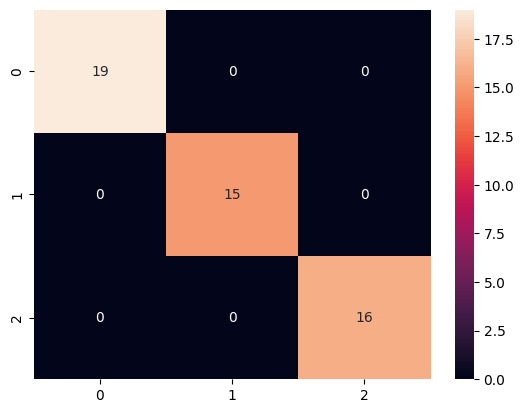

In [29]:
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True)

In [30]:
print("informe de classificació:")
print(classification_report(y_test, y_pred))

informe de classificació:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        15
           2       1.00      1.00      1.00        16

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50

